In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

from itertools import product

import cmocean
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree, Stereographic, AlbersEqualArea
import warnings

import pandas as pd
import geopandas as gpd

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
sample_points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
voronoi_ocean_path = Path(folder_path, "SamplePoints/VoronoiOceanPolygons.shp")
input_path = Path(folder_path, f"VoronoiConnectivity/")

In [3]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
axis_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [4]:
# Load the samplepoints and the voronoi polygons
sample_points = gpd.read_file(sample_points_path).to_crs(map_projection).sort_values(by="order")
sample_ids = sample_points.SampleID
voronoi_polygons = gpd.read_file(voronoi_polygons_path).to_crs(map_projection)
connectivity_matrix = pd.read_csv("Figures/connectivity_matrices/connectivity_matrix.csv", index_col="SampleID")

In [5]:
figure_outpath = Path("/gxfs_work/geomar/smomw597/2025_copepods/Figures/")
map_outpath = Path(figure_outpath, "connectivity_maps/")

# Functions

In [6]:
non_genetic_sample_ids = sample_ids.where(sample_points.GenomicDat == False).dropna().tolist()

def drop_non_genetic(matrix):
        return matrix.drop(columns=non_genetic_sample_ids, index=non_genetic_sample_ids, errors="ignore")

In [7]:
def basemap(ax, extent=extent):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [8]:
def define_cmap(cmap_input='coolwarm', cmdiscrete=False, value_min=None, value_max=None):
        if isinstance(cmap_input, str):
                cmap = mpl.colormaps.get_cmap(cmap_input)
        elif isinstance(cmap_input, type(cmocean.cm.haline)):
                cmap = cmap_input
        elif not isinstance(cmap_input, type(cmocean.cm.haline)):
                return print("Please input colormap or colormap name (str).")

        vmax = 10**np.ceil(np.log10(value_max))
        vmin = 10**np.floor(np.log10(value_min))
        sample_steps = vmax-vmin
        norm = colors.Normalize(vmin=value_min, vmax=value_max)
        # resample the colormap into the amount of discrete steps of difference between the vmin and vmax in power of 10
        difference_of_magnitude = (np.log10(vmax) - np.log10(vmin)).astype(int) 
        if (difference_of_magnitude >2):
                while difference_of_magnitude > 10:
                        difference_of_magnitude=np.ceil(difference_of_magnitude/2).astype(int)
                sample_steps = difference_of_magnitude
                norm = LogNorm(vmin=vmin, vmax=vmax,)
        else:
                sample_steps = value_max-value_min
        if cmdiscrete:
                cmap = cmap.resampled(sample_steps)
                cmap.set_under(color="#00000000") # force the first color entry to be invisible
        return cmap, norm

# Maps

In [9]:
def draw_voronoi_polygons(ax, cmap="rainbow", edgecolor="black", facealpha=0.2):
        voronoi_polys = voronoi_polygons.copy().to_crs(map_projection)
        voronoi_polys.plot(ax=ax, alpha=facealpha, column="PolygonID", cmap=cmap)
        voronoi_polys.boundary.plot(ax=ax, color=edgecolor,)

def legend_without_duplicate_labels(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique))


In [10]:
marker_genetic = pd.DataFrame(
    data=np.array([["dodgerblue", "s"], ["green", "^"],]),
    index=[True, False], 
    columns=["color", "marker"],
    )

marker_kind = pd.DataFrame(
    data=np.array([["darkred", "s",],["dodgerblue", "^",], ["salmon", "s",]]),
    index=["real", "digital", "moved"], 
    columns=["color", "marker",],
    )
marker_kind

,color,marker
real,darkred,s
digital,dodgerblue,^
moved,salmon,s


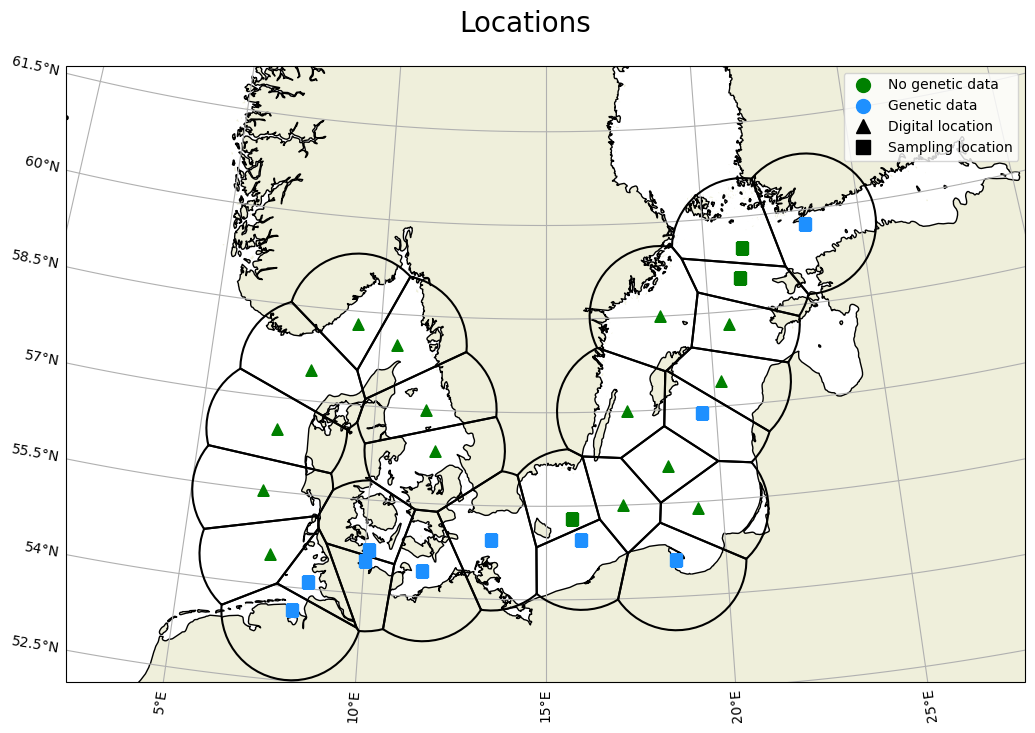

In [11]:
show_polygons = True

fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
if show_polygons:
        draw_voronoi_polygons(ax_map, facealpha=0)

for index, (name, sampleID, sampleID_old, 
        kind, geneticData, order, 
        sea, geometry) in sample_points.iterrows():
        lon, lat = geometry.x, geometry.y
        marker = marker_kind["marker"][kind]
        color = marker_genetic["color"][geneticData]
        ax_map.scatter(lon, lat, marker=marker, color=color, zorder=5, label=kind, s=65)

blue = Line2D([], [], color="green", marker='o', linestyle="None",
                          markersize=10, label="No genetic data")
red = Line2D([], [], color="dodgerblue", marker='o', linestyle="None",
                          markersize=10, label="Genetic data")

triangle = Line2D([], [], color="k", marker='^', linestyle="None",
                          markersize=10, label="Digital location")
square = Line2D([], [], color="k", marker='s', linestyle="None",
                          markersize=10, label="Sampling location")

plt.legend(handles=[blue, red, triangle, square])
# plt.savefig(Path(figure_outpath, "EmptyMap.pdf"), format="pdf")
plt.show()

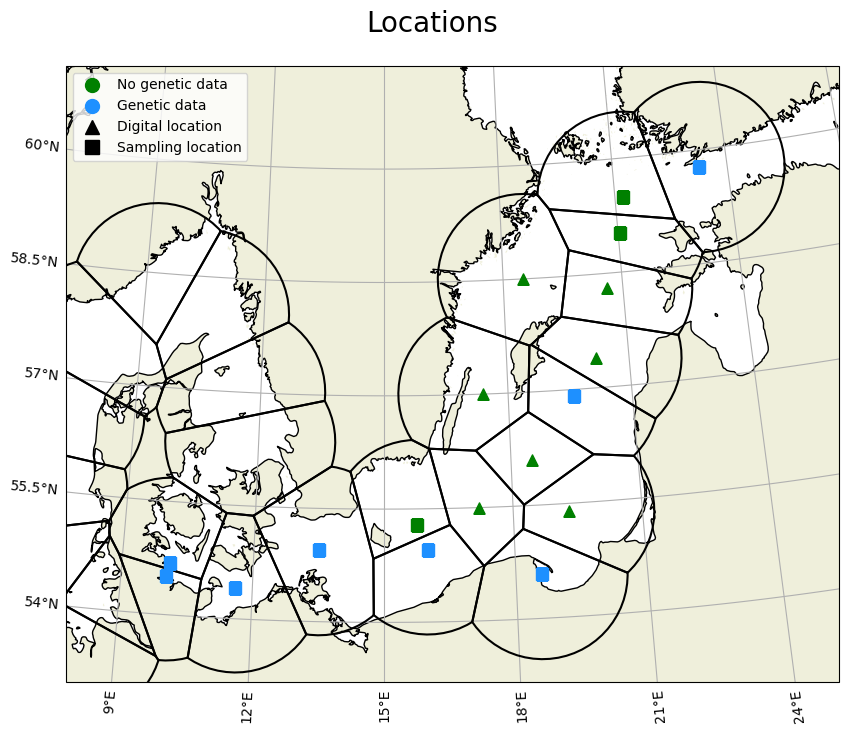

In [12]:
show_polygons = True

fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, (8, 25, 53, 61))
if show_polygons:
        draw_voronoi_polygons(ax_map, facealpha=0)

for index, (name, sampleID, sampleID_old, 
        kind, geneticData, order, 
        sea, geometry) in sample_points.iterrows():
        if sea =="baltic":
                lon, lat = geometry.x, geometry.y
                marker = marker_kind["marker"][kind]
                color = marker_genetic["color"][geneticData]
                ax_map.scatter(lon, lat, marker=marker, color=color, zorder=5, label=kind, s=65)

blue = Line2D([], [], color="green", marker='o', linestyle="None",
                          markersize=10, label="No genetic data")
red = Line2D([], [], color="dodgerblue", marker='o', linestyle="None",
                          markersize=10, label="Genetic data")

triangle = Line2D([], [], color="k", marker='^', linestyle="None",
                          markersize=10, label="Digital location")
square = Line2D([], [], color="k", marker='s', linestyle="None",
                          markersize=10, label="Sampling location")

plt.legend(handles=[blue, red, triangle, square], loc="upper left")
# plt.savefig(Path(figure_outpath, "EmptyMap.pdf"), format="pdf")
plt.show()

## Connectivity Map

In [13]:
def read_cmap(cmap_input):
        if isinstance(cmap_input, str):
                return mpl.colormaps.get_cmap(cmap_input)
        elif isinstance(cmap_input, type(cmocean.cm.haline)):
                return cmap_input
        elif not isinstance(cmap_input, type(cmocean.cm.haline)):
                return print("Please input colormap or colormap name (str).")

In [14]:
def getXY(point):
    return (point.x.values[0], point.y.values[0])

In [15]:
def extent_to_rectangle(extent):
    x, y = extent[0], extent[2]
    width = extent[1] - extent[0]
    height = extent[3] - extent[2]
    return (x, y), width, height


In [16]:
def draw_self_connections(ax, matrix, norm, cmap=cmocean.cm.matter):
        sample_points = gpd.read_file(sample_points_path).to_crs(map_projection).sort_values(by="order").set_index("SampleID")
        sample_points = sample_points[sample_points["SampleKind"] != "digital"]
        max_connection = matrix.max(axis=None)

        self_connections = pd.DataFrame(
                data=[[index, matrix[index][index]] for index in matrix.index],
                columns=["SampleID","self_connection"]
        ).set_index("SampleID")
        sample_points = sample_points.join(self_connections)
        
        colors = [cmap(norm(self_connection),) for self_connection in sample_points.self_connection]
        sizes = [100 + (self_connection/max_connection)*500 for self_connection in sample_points.self_connection]
        sample_points.plot(ax=ax, color=colors, markersize=sizes, edgecolor="k",)

In [17]:
def draw_connections(ax, matrix, norm, cmap=cmocean.cm.haline,):
        sample_points = gpd.read_file(sample_points_path).to_crs(map_projection).sort_values(by="order")
        for (incomming, outgoing) in product(matrix, repeat=2):
                n_connections = matrix[outgoing][incomming]
                if np.isnan(n_connections):
                        continue # abbort if there are no connections
                extent = ax.get_extent()
                xy_outgoing = getXY(sample_points[sample_points.SampleID == outgoing].geometry)
                xy_incomming = getXY(sample_points[sample_points.SampleID == incomming].geometry)
                if not (extent[0] < xy_incomming[0] < extent[1]) or not extent[0] < xy_outgoing[0] < extent[1]:
                        continue  # abbort if there are no connections within the extent
                color = cmap(norm(n_connections))
                con = ConnectionPatch(
                        xyA=xy_outgoing, xyB=xy_incomming, coordsA=ax.transData,
                        color=color, lw=2.2, zorder=5, edgecolor="k",
                        shrinkA=10, shrinkB=10,
                )
                con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                con.set_connectionstyle("Arc3,rad=0.3")
                ax.add_artist(con)

In [28]:
def make_connectivitymap(
        matrix, 
        map_projection=map_projection, mapsize=mapsize, suptitle="connectivity Map",
        only_genetic=True, show_polygons=False, map_extent=None,
        cmap_scatter=cmocean.cm.matter, cmap = cmocean.cm.haline,
        filename=None,
        ):
        matrix = matrix.mask(matrix == 0)
        if only_genetic:
                matrix = drop_non_genetic(matrix)
        if not map_extent:
                map_extent=extent
        
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        cmap = read_cmap(cmap)
        (cmap, norm) = define_cmap(cmap, cmdiscrete=True, value_min=min_connection, value_max=max_connection)
        
        fig = plt.figure(figsize=(14,10))
        # Main Map in top left
        ax_main = fig.add_axes([0.05, 0.4, 0.7, 0.55], projection=map_projection)
        if show_polygons:
                draw_voronoi_polygons(ax=ax_main, facealpha=0)
        basemap(ax_main, map_extent)
        draw_connections(ax_main, matrix, norm=norm, cmap=cmap)
        draw_self_connections(ax_main, matrix, norm=norm, cmap=cmap)
        
        # Zoom onto west baltic in bottom left
        ax_westbaltic = fig.add_axes([0.05, 0.05, 0.7, 0.3], projection=map_projection)
        basemap(ax_westbaltic)
        westbaltic_extent = [9.5,16.5,54,55.5,]
        ax_westbaltic.set_extent(westbaltic_extent, PlateCarree())
        draw_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)
        draw_self_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)

        cax_arrows = fig.add_axes([0.75, 0.05, 0.03, 0.9])
        fig.colorbar(ScalarMappable(norm, cmap), cax=cax_arrows, label="relative normalized connection")
        cax_arrows.minorticks_off()

        westbaltic_xy, westbaltic_width, westbaltic_height = extent_to_rectangle(westbaltic_extent)
        ax_main.add_patch(Rectangle(
                westbaltic_xy, westbaltic_width, westbaltic_height,
                fill=False, color='k', lw=1.5, zorder=100, transform=Geodetic(),
        ))

        if filename is not None:
                plt.savefig(Path(figure_outpath, filename), format="pdf")
        plt.show()

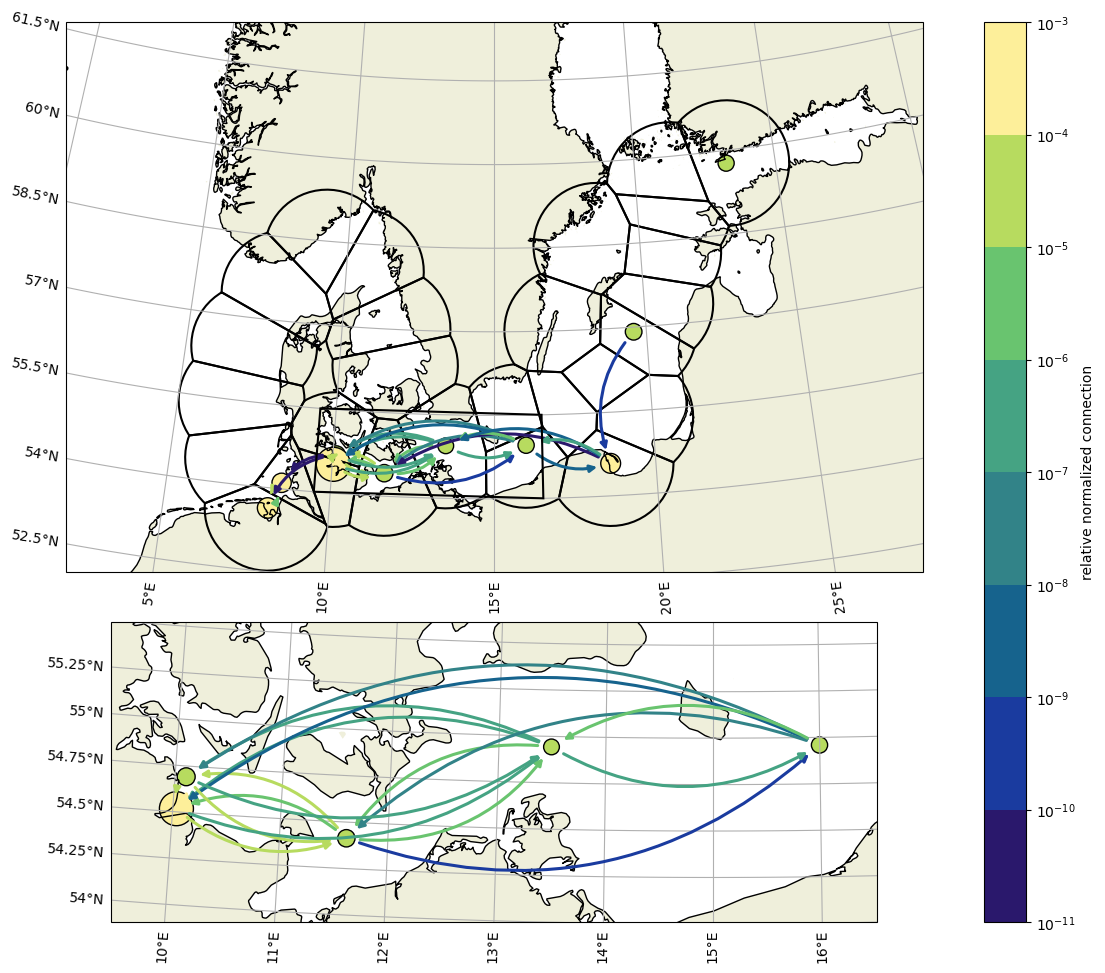

In [29]:
make_connectivitymap(
        matrix=connectivity_matrix, 
        show_polygons=True,
        # filename="connectivityMap_genetic.pdf"
)

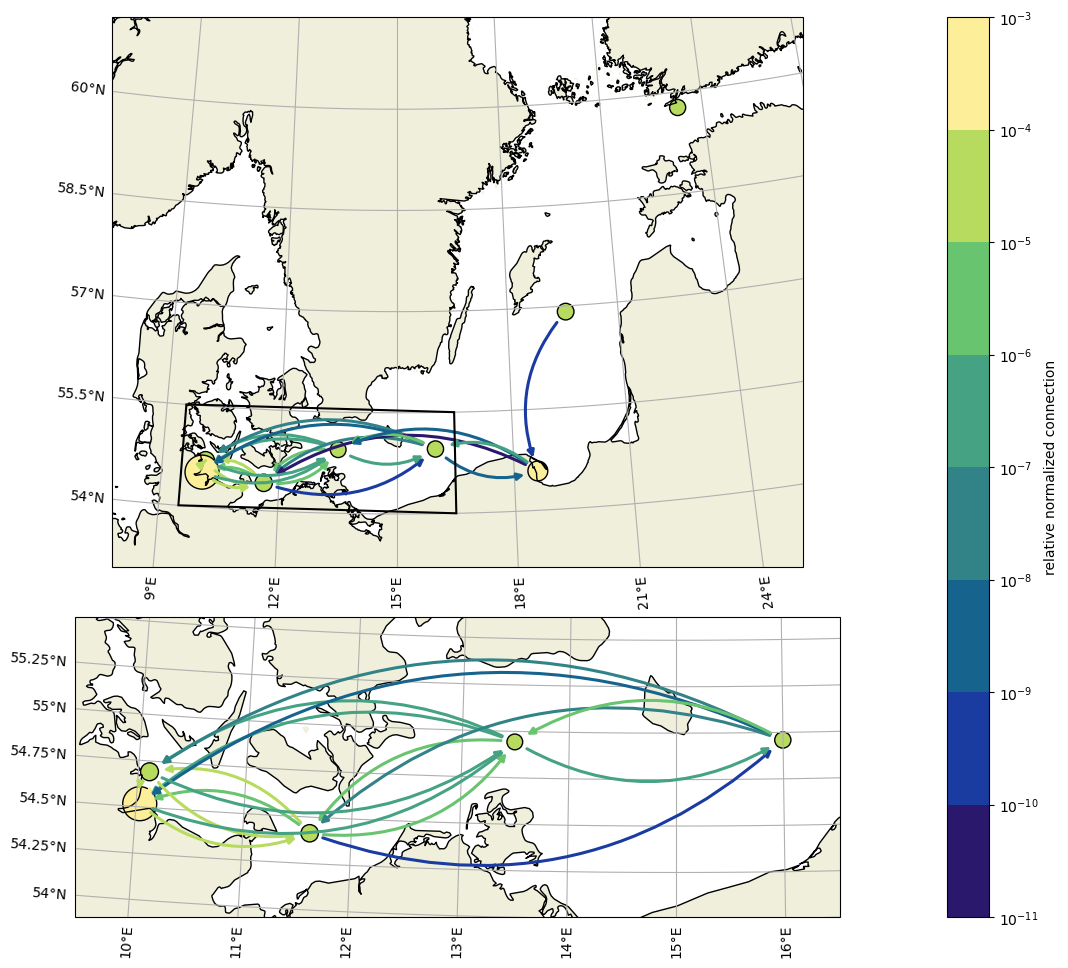

In [ ]:
make_connectivitymap(
        matrix=df_cmatrix_normalized_relative_baltic_genetic, only_genetic=True, map_extent=(8, 25, 53, 61),
        # filename="connectivityMap_baltic_genetic.pdf"
)

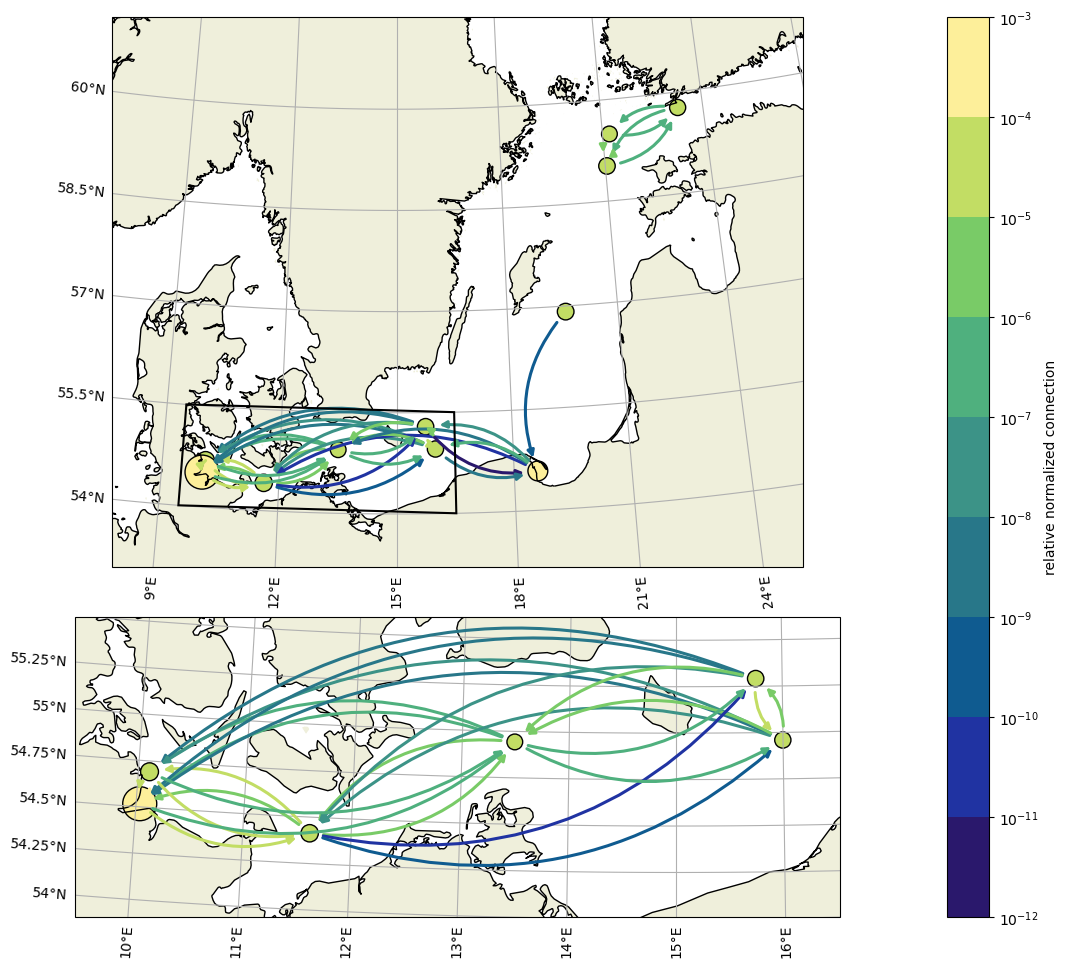

In [ ]:
make_connectivitymap(
        matrix=df_cmatrix_normalized_relative_baltic_sampled, only_genetic=False, map_extent=(8, 25, 53, 61),
        # filename="connectivityMap_baltic_sampled.pdf"
)